# Phase 3 — Baseline

[`walkthrough/phase3.md`](../walkthrough/phase3.md)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/data.csv"
df = pd.read_csv(DATA_PATH)

LEAKAGE_COLS = ["Disposable_Income", "Desired_Savings", "Desired_Savings_Percentage"]
df["Goal_Met"] = (df["Disposable_Income"] >= df["Desired_Savings"]).astype(int)

expense_cols = [
    "Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport", "Eating_Out",
    "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous",
]
ratio_cols = []
for c in expense_cols:
    ratio_col = f"{c}_Ratio"
    df[ratio_col] = df[c] / df["Income"]
    ratio_cols.append(ratio_col)

engineered = pd.get_dummies(
    df[["Income", "Age", "Dependents", "Occupation", "City_Tier"] + ratio_cols + ["Goal_Met"]],
    columns=["Occupation", "City_Tier"],
    drop_first=False,
)

print(f"Engineered feature matrix shape: {engineered.shape}")
engineered.head()

Engineered feature matrix shape: (20000, 22)


,Income,Age,Dependents,Rent_Ratio,Loan_Repayment_Ratio,Insurance_Ratio,Groceries_Ratio,Transport_Ratio,Eating_Out_Ratio,Entertainment_Ratio,Utilities_Ratio,Healthcare_Ratio,Education_Ratio,Miscellaneous_Ratio,Goal_Met,Occupation_Professional,Occupation_Retired,Occupation_Self_Employed,Occupation_Student,City_Tier_Tier_1,City_Tier_Tier_2,City_Tier_Tier_3
0,44637.249636,49,0,0.30,0.000000,0.049432,0.149175,0.059076,0.037005,0.034415,0.065232,0.034655,0.000000,0.018629,1,False,False,True,False,True,False,False
1,26858.596592,34,2,0.20,0.000000,0.032374,0.104936,0.057450,0.024178,0.039103,0.060545,0.042346,0.057774,0.021008,1,False,True,False,False,False,True,False
2,50367.605084,35,1,0.15,0.091569,0.043715,0.125343,0.063958,0.030055,0.034215,0.066877,0.043252,0.062739,0.012476,1,False,False,False,True,False,False,True
3,101455.600247,21,0,0.15,0.067117,0.048193,0.144794,0.070042,0.049679,0.028172,0.060406,0.045055,0.000000,0.024898,1,False,False,True,False,False,False,True
4,24875.283548,52,4,0.20,0.125129,0.025564,0.121982,0.051302,0.027852,0.026540,0.043927,0.046998,0.058098,0.020724,1,True,False,False,False,False,True,False


## Train/test split

In [2]:
X_full = engineered.drop(columns=["Goal_Met"])
y = engineered["Goal_Met"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).rename({0: "Goal not met (0)", 1: "Goal met (1)"}))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).rename({0: "Goal not met (0)", 1: "Goal met (1)"}))

Train: (16000, 21), Test: (4000, 21)

Train class balance:
Goal_Met
Goal met (1)        0.994375
Goal not met (0)    0.005625
Name: proportion, dtype: float64

Test class balance:
Goal_Met
Goal met (1)        0.9945
Goal not met (0)    0.0055
Name: proportion, dtype: float64


## Majority-class baseline

In [3]:
def evaluate(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return {
        "model": name,
        "accuracy": accuracy,
        "precision_0": precision[0], "recall_0": recall[0], "f1_0": f1[0],
        "precision_1": precision[1], "recall_1": recall[1], "f1_1": f1[1],
        "f1_macro": f1_macro,
    }

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

results = [evaluate("Majority-class baseline", y_test, pred_dummy)]
pd.DataFrame(results).set_index("model").round(4)

,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
Majority-class baseline,0.9945,0.0,0.0,0.0,0.9945,1.0,0.9972,0.4986


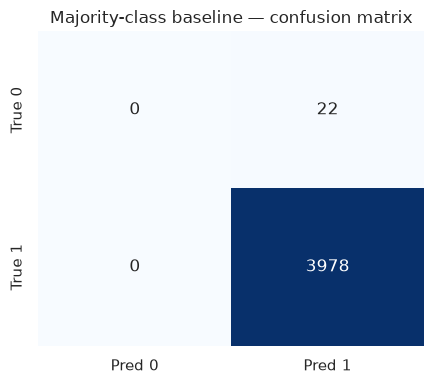

In [4]:
cm_dummy = confusion_matrix(y_test, pred_dummy)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(
    cm_dummy, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
    xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"],
)
ax.set_title("Majority-class baseline — confusion matrix")
fig.tight_layout()
plt.show()

## Plain logistic regression

In [5]:
candidate_cols = ["Income"] + ratio_cols
train_df = df.loc[X_train.index]  # training rows only
target_corr = train_df[candidate_cols + ["Goal_Met"]].corr()["Goal_Met"].drop("Goal_Met")
target_corr.sort_values(key=lambda s: -s.abs()).to_frame("corr_with_Goal_Met")

,corr_with_Goal_Met
Loan_Repayment_Ratio,-0.152423
Rent_Ratio,-0.109287
Education_Ratio,-0.057006
Groceries_Ratio,-0.051772
Insurance_Ratio,-0.041451
Eating_Out_Ratio,-0.035675
Utilities_Ratio,-0.035195
Entertainment_Ratio,-0.023827
Transport_Ratio,-0.020075
Healthcare_Ratio,-0.017783


In [6]:
baseline_features = ["Income", "Loan_Repayment_Ratio", "Rent_Ratio"]

X_train_min = X_train[baseline_features]
X_test_min = X_test[baseline_features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_min)
X_test_scaled = scaler.transform(X_test_min)

logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)
pred_logreg = logreg.predict(X_test_scaled)

results.append(evaluate("Plain LogisticRegression (Income + 2 ratios)", y_test, pred_logreg))
pd.DataFrame(results).set_index("model").round(4)

,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
Majority-class baseline,0.9945,0.0,0.0,0.0,0.9945,1.0000,0.9972,0.4986
Plain LogisticRegression (Income + 2 ratios),0.9942,0.0,0.0,0.0,0.9945,0.9997,0.9971,0.4986


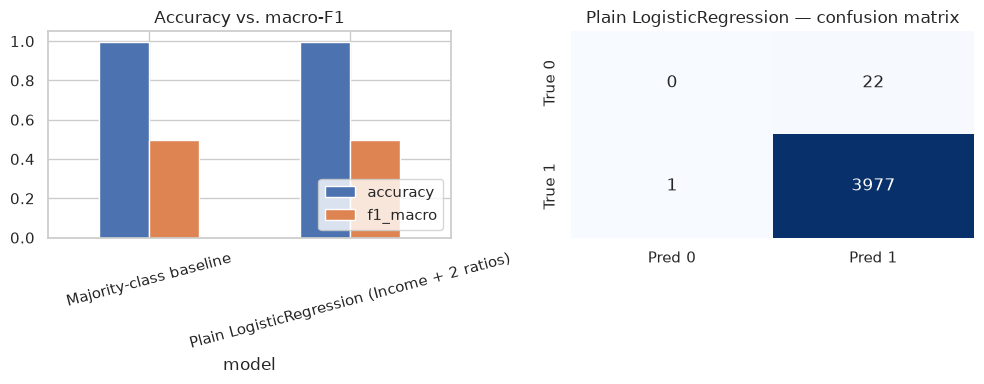

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

metrics_df = pd.DataFrame(results).set_index("model")
metrics_df[["accuracy", "f1_macro"]].plot(kind="bar", ax=axes[0], rot=15)
axes[0].set_title("Accuracy vs. macro-F1")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="lower right")

cm_logreg = confusion_matrix(y_test, pred_logreg)
sns.heatmap(
    cm_logreg, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1],
    xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"],
)
axes[1].set_title("Plain LogisticRegression — confusion matrix")

fig.tight_layout()
plt.show()